In [62]:
!pip install -q clickhouse-connect pandas seaborn


[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [ ]:
from config import client
import pandas as pd

True

In [41]:
batch_number_in_query = "SELECT * FROM zoho_books_analytics.batch_number_in"

result = client.query(batch_number_in_query)

batch_number_in_df = pd.DataFrame(result.result_rows, columns=[col for col in result.column_names])

# print(batch_number_in_df.head())

### Column and Their Descriptions

batch_in_id → Unique identifier for the batch-in transaction.

product_id → Identifier of the associated product.

batch_number → The assigned batch number.

batch_reference → Reference information for the batch.

batch_manufactured_date → Manufacturing date of the batch.

batch_expiry_date → Expiration date of the batch.

quantity_in → Quantity received in the batch.

balance_quantity → 

warehouse_id → Identifier of the warehouse storing the batch.

entity_type → Type of entity linked to the batch.

account_balance_id → Identifier for account balance reference.

account_split_id → Identifier for account split reference.

bill_id → Identifier of the related bill.

bill_item_id → Identifier of the related bill item.

creditnotes_id → Identifier of the related credit note.

credit_notes_item_id → Identifier of the related credit note item.

inventory_adjustment_id → Identifier of inventory adjustment.

inventory_adjustment_item_id → Identifier of inventory adjustment item.

bundle_id → Identifier of the product bundle (if applicable).

created_time → Timestamp when the record was created.

last_modified_time → Timestamp when the record was last modified.

purchase_receive_id → Identifier of the purchase receive document.

purchase_receive_item_id → Identifier of the purchase receive item.

sales_return_receive_item_id → Identifier of the sales return receive item.

sales_return_receive_id → Identifier of the sales return receive document.


In [80]:
batch_number_in_df.isna().sum()

batch_in_id                       0
product_id                        0
batch_number                      0
batch_reference                   0
batch_manufactured_date         219
batch_expiry_date               195
quantity_in                       0
balance_quantity                  0
warehouse_id                      0
entity_type                       0
account_balance_id                0
account_split_id                  0
bill_id                           0
bill_item_id                      0
creditnotes_id                    0
credit_notes_item_id              0
inventory_adjustment_id           0
inventory_adjustment_item_id      0
bundle_id                         0
created_time                      0
last_modified_time                0
purchase_receive_id               0
purchase_receive_item_id          0
sales_return_receive_item_id      0
sales_return_receive_id           0
shelf_life_days                 222
dtype: int64

In [65]:
batch_number_in_df['batch_manufactured_date'].isna().sum()

np.int64(219)

In [67]:
batch_number_in_df['batch_expiry_date'].isna().sum()

np.int64(195)

In [48]:
# Convert to datetime if not already
batch_number_in_df['batch_manufactured_date'] = pd.to_datetime(batch_number_in_df['batch_manufactured_date'], errors='coerce')
batch_number_in_df['batch_expiry_date'] = pd.to_datetime(batch_number_in_df['batch_expiry_date'], errors='coerce')

# Expiry date before manufactured
anomalies_date = batch_number_in_df[batch_number_in_df['batch_expiry_date'] < batch_number_in_df['batch_manufactured_date']]
anomalies_date


,batch_in_id,product_id,batch_number,batch_reference,batch_manufactured_date,batch_expiry_date,quantity_in,balance_quantity,warehouse_id,entity_type,...,credit_notes_item_id,inventory_adjustment_id,inventory_adjustment_item_id,bundle_id,created_time,last_modified_time,purchase_receive_id,purchase_receive_item_id,sales_return_receive_item_id,sales_return_receive_id
236,1410873000000850886,1410873000000138071,B19164,AZ3325,2018-09-19,1969-12-31,32400.00,0.00,1410873000000521935,bill,...,,,,,2018-08-22 21:40:32+00:00,2018-10-23 09:15:20+00:00,,,,
237,1410873000000850943,1410873000000138181,B19344,AZ3328,2018-09-27,1969-12-31,28800.00,0.00,1410873000000521935,bill,...,,,,,2018-08-22 21:52:54+00:00,2018-10-23 09:28:59+00:00,,,,
249,1410873000000852406,1410873000000139456,B19231,AZ3401,2018-09-21,1969-12-31,2000.00,0.00,1410873000000521935,bill,...,,,,,2018-08-22 21:25:54+00:00,2019-06-11 20:04:44+00:00,,,,
250,1410873000000852408,1410873000000139935,B19235,AZ3401,2018-09-21,1969-12-31,4000.00,0.00,1410873000000521935,bill,...,,,,,2018-08-22 21:25:54+00:00,2019-06-11 20:04:44+00:00,,,,
251,1410873000000852410,1410873000000139656,B19233,AZ3401,2018-09-21,1969-12-31,10000.00,0.00,1410873000000521935,bill,...,,,,,2018-08-22 21:25:54+00:00,2019-06-11 20:04:44+00:00,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3936,1410873000008178045,1410873000000136917,B24427A,AZ3199,2018-08-16,1969-12-31,5000.00,0.00,1410873000000521961,transfer_order,...,,1410873000008178015,1410873000008178029,,2019-08-03 02:25:19+00:00,2019-11-22 02:09:04+00:00,,,,
4896,1410873000011295281,1410873000000138253,B18824A-India,AZ3205,2018-09-06,1969-12-31,7488.00,0.00,1410873000000521961,inventory_adjustment_by_quantity,...,,1410873000011295275,1410873000011295277,,2019-12-30 22:28:17+00:00,2020-01-13 18:53:10+00:00,,,,
5464,1410873000012836121,1410873000001872321,A0081356-Indonesia,AZD1212-Indonesia,2019-10-10,1969-12-31,2000.00,0.00,1410873000001632376,bill,...,,,,,2020-03-02 15:58:45+00:00,2020-03-02 16:20:38+00:00,,,,
21620,1410873000052515481,1410873000047473654,17681,AZD2390-USA,2023-07-19,1969-12-31,1090.00,0.00,1410873000048741070,bill,...,,,,,2023-07-20 18:32:38+00:00,2024-01-09 19:27:13+00:00,,,,


In [68]:
# Shelf life too long/short (e.g., <1 day or >10 years) # Here 10 can be changed to threshold
batch_number_in_df['shelf_life_days'] = (batch_number_in_df['batch_expiry_date'] - batch_number_in_df['batch_manufactured_date']).dt.days
# anomalies_shelf = batch_number_in_df[(batch_number_in_df['shelf_life_days'] < 1) | (batch_number_in_df['shelf_life_days'] > 3650)]
anomalies_shelf = batch_number_in_df[(batch_number_in_df['shelf_life_days'] < 1)]
len(anomalies_shelf)

4679

In [50]:
# Convert to numeric
batch_number_in_df['quantity_in'] = pd.to_numeric(batch_number_in_df['quantity_in'], errors='coerce')
batch_number_in_df['balance_quantity'] = pd.to_numeric(batch_number_in_df['balance_quantity'], errors='coerce')

# Negative or NaN values
anomalies_qty = batch_number_in_df[(batch_number_in_df['quantity_in'] < 0) | (batch_number_in_df['balance_quantity'] < 0)]

anomalies_qty

,batch_in_id,product_id,batch_number,batch_reference,batch_manufactured_date,batch_expiry_date,quantity_in,balance_quantity,warehouse_id,entity_type,...,inventory_adjustment_id,inventory_adjustment_item_id,bundle_id,created_time,last_modified_time,purchase_receive_id,purchase_receive_item_id,sales_return_receive_item_id,sales_return_receive_id,shelf_life_days


In [ ]:
# Balance > quantity_in # has customs # inventory adjustment
anomalies_balance = batch_number_in_df[batch_number_in_df['balance_quantity'] > batch_number_in_df['quantity_in']]
anomalies_balance

,batch_in_id,product_id,batch_number,batch_reference,batch_manufactured_date,batch_expiry_date,quantity_in,balance_quantity,warehouse_id,entity_type,...,inventory_adjustment_id,inventory_adjustment_item_id,bundle_id,created_time,last_modified_time,purchase_receive_id,purchase_receive_item_id,sales_return_receive_item_id,sales_return_receive_id,shelf_life_days


In [24]:
# Outlier detection using IQR
Q1, Q3 = batch_number_in_df['quantity_in'].quantile([0.25, 0.75])
IQR = Q3 - Q1
anomalies_outliers = batch_number_in_df[(batch_number_in_df['quantity_in'] < Q1 - 1.5*IQR) | (batch_number_in_df['quantity_in'] > Q3 + 1.5*IQR)]
anomalies_outliers

,batch_in_id,product_id,batch_number,batch_reference,batch_manufactured_date,batch_expiry_date,quantity_in,balance_quantity,warehouse_id,entity_type,...,inventory_adjustment_id,inventory_adjustment_item_id,bundle_id,created_time,last_modified_time,purchase_receive_id,purchase_receive_item_id,sales_return_receive_item_id,sales_return_receive_id,shelf_life_days


In [53]:
# Flag warehouses holding <1% or >50% of records (threshold needs to be changed)
warehouse_dist = batch_number_in_df['warehouse_id'].value_counts(normalize=True)

anomalies_warehouse = warehouse_dist[(warehouse_dist < 0.01) | (warehouse_dist > 0.5)]
anomalies_warehouse

warehouse_id
1410873000003311374    0.009430
1410873000000521953    0.008100
1410873000093966463    0.006992
1410873000050950633    0.006697
1410873000029014436    0.006303
                         ...   
1410873000004423001    0.000025
1410873000037879829    0.000025
1410873000015173636    0.000025
1410873000130100278    0.000025
1410873000027661576    0.000025
Name: proportion, Length: 65, dtype: float64

In [54]:
# Record modified before creation
anomalies_time = batch_number_in_df[batch_number_in_df['last_modified_time'] < batch_number_in_df['created_time']]
anomalies_time

,batch_in_id,product_id,batch_number,batch_reference,batch_manufactured_date,batch_expiry_date,quantity_in,balance_quantity,warehouse_id,entity_type,...,inventory_adjustment_id,inventory_adjustment_item_id,bundle_id,created_time,last_modified_time,purchase_receive_id,purchase_receive_item_id,sales_return_receive_item_id,sales_return_receive_id,shelf_life_days


In [ ]:
# Sudden spike detection: group by day # need
daily_counts = batch_number_in_df['created_time'].dt.date.value_counts().sort_index()   # in one day how many records are created
mean, std = daily_counts.mean(), daily_counts.std()
anomalies_spike = daily_counts[daily_counts > mean + 3*std]  # 3σ rule
len(anomalies_spike)    #-> in 45 days there were more records created than expected

45

In [59]:
# Check unique values
batch_number_in_df['entity_type'].value_counts()

entity_type
bill                                35156
inventory_adjustment_by_quantity     3114
transfer_order                       1775
creditnote                            459
opening_balance                       113
Name: count, dtype: int64

In [61]:
# Flag unexpected categories (define expected ones)
expected_types = {"bill", "inventory_adjustment_by_quantity", "transfer_order", "creditnote", "opening_balance"}  
anomalies_entity = batch_number_in_df[~batch_number_in_df['entity_type'].isin(expected_types)]
anomalies_entity


,batch_in_id,product_id,batch_number,batch_reference,batch_manufactured_date,batch_expiry_date,quantity_in,balance_quantity,warehouse_id,entity_type,...,inventory_adjustment_id,inventory_adjustment_item_id,bundle_id,created_time,last_modified_time,purchase_receive_id,purchase_receive_item_id,sales_return_receive_item_id,sales_return_receive_id,shelf_life_days


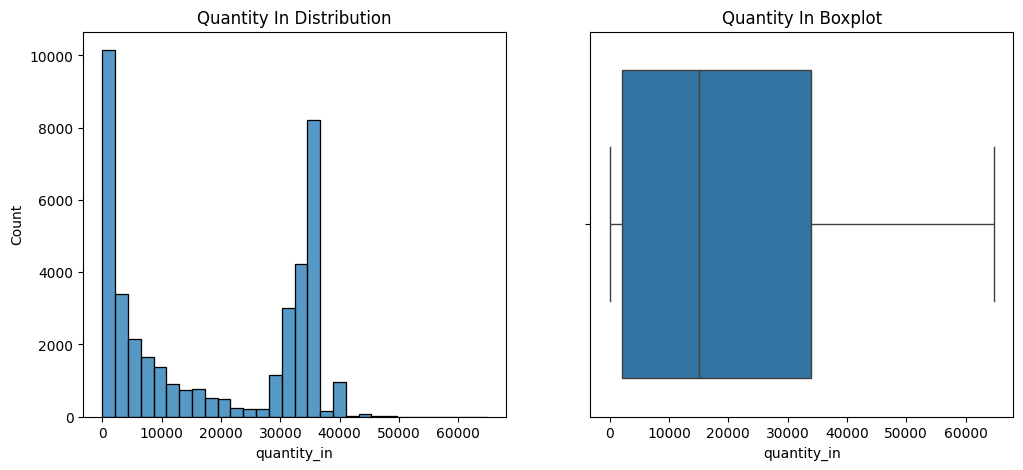

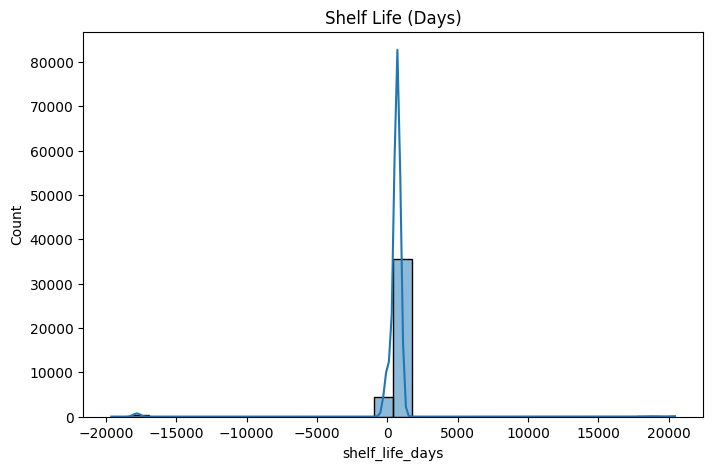

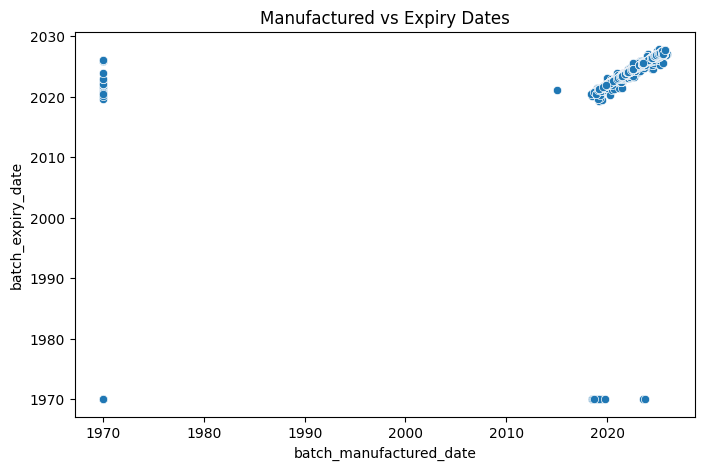

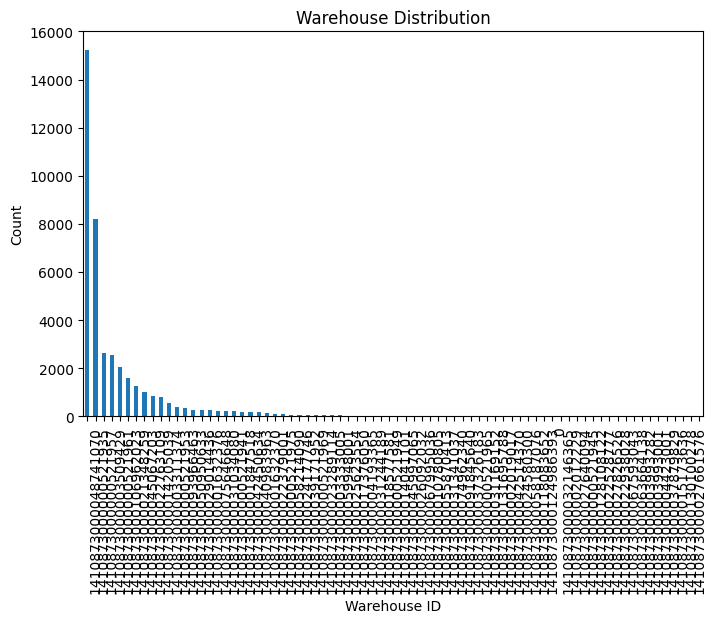

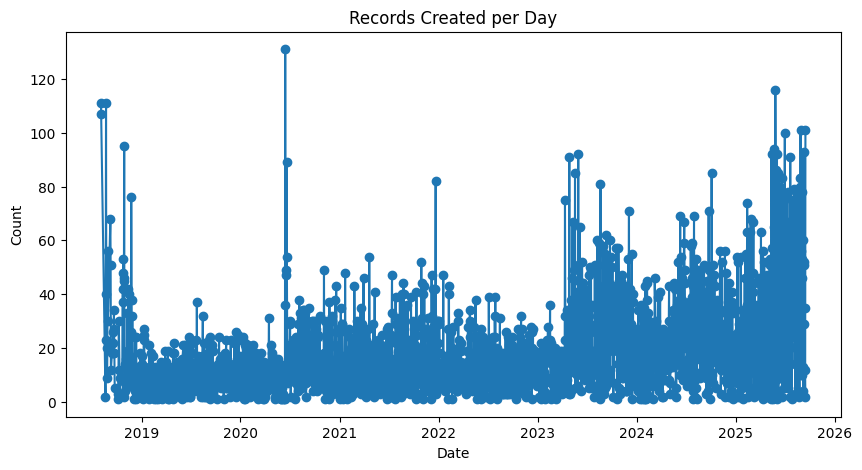

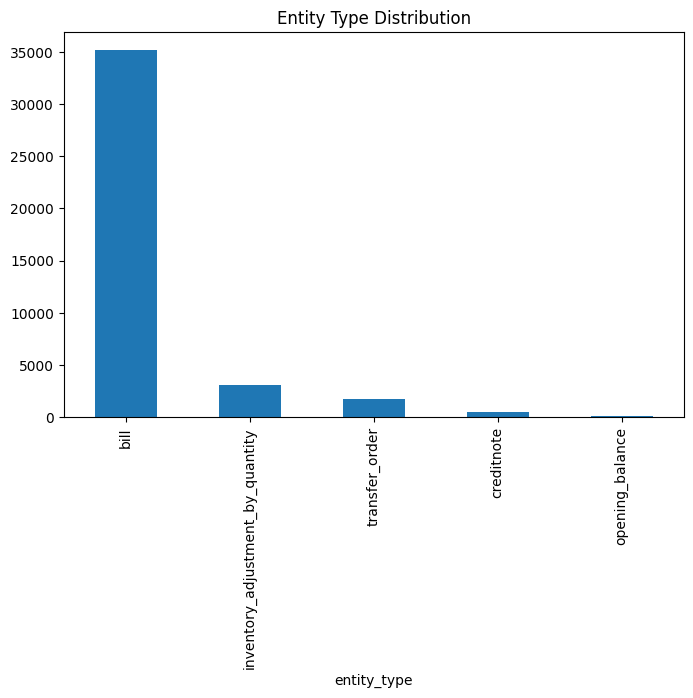

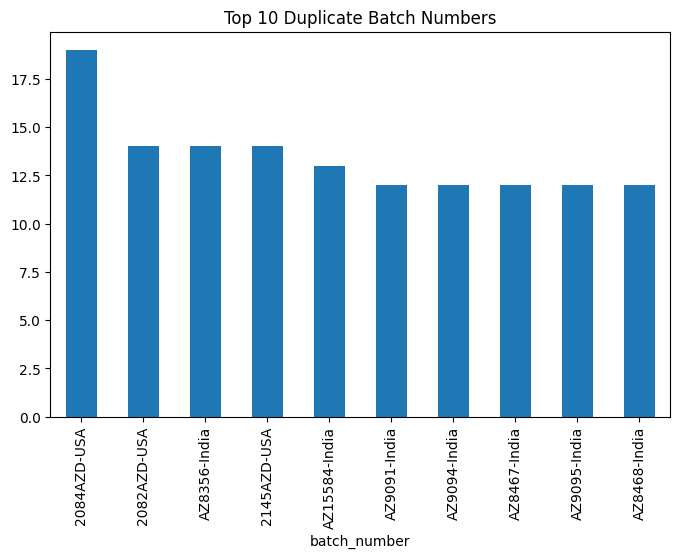

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Quantity distribution
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(batch_number_in_df['quantity_in'], bins=30, ax=axes[0])
axes[0].set_title("Quantity In Distribution")

sns.boxplot(x=batch_number_in_df['quantity_in'], ax=axes[1])
axes[1].set_title("Quantity In Boxplot")
plt.show()

# 2. Shelf life
plt.figure(figsize=(8,5))
sns.histplot(batch_number_in_df['shelf_life_days'], bins=30, kde=True)
plt.title("Shelf Life (Days)")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='batch_manufactured_date', y='batch_expiry_date', data=batch_number_in_df)
plt.title("Manufactured vs Expiry Dates")
plt.show()

# plt.figure(figsize=(8,5))
# batch_number_in_df['warehouse_id'].value_counts().plot(kind='bar')
# plt.title("Warehouse Distribution")
# plt.xlabel("Warehouse ID")
# plt.ylabel("Count")
# plt.show()


# daily_counts = batch_number_in_df['created_time'].dt.date.value_counts().sort_index()
# plt.figure(figsize=(10,5))
# daily_counts.plot(kind='line', marker='o')
# plt.title("Records Created per Day")
# plt.xlabel("Date")
# plt.ylabel("Count")
# plt.show()

# 5. Entity type distribution
plt.figure(figsize=(8,5))
batch_number_in_df['entity_type'].value_counts().plot(kind='bar')
plt.title("Entity Type Distribution")
plt.show()

# 6. Duplicate batch numbers
duplicate_counts = batch_number_in_df['batch_number'].value_counts()
dup_top10 = duplicate_counts[duplicate_counts > 1].head(10)
plt.figure(figsize=(8,5))
dup_top10.plot(kind='bar')
plt.title("Top 10 Duplicate Batch Numbers")
plt.show()
